У цьому завданні використовується набір даних `Yulu`

### Профіль колонок набору даних:

- **datetime**: дата та час зібрані погодинно
- **season**: сезон (1: весна, 2: літо, 3: осінь, 4: зима)
- **holiday**: чи є день святковим (витягнуто з http://dchr.dc.gov/page/holiday-schedule)
- **workingday**: якщо день не є вихідним або святковим, то позначається як 1, в іншому випадку – 0.
- **weather**:
  1. Ясно, Мало хмарно, частково хмарно
  2. Туман + Хмарно, Туман + Розірвані хмари, Туман + Мало хмарно, Туман
  3. Легкий сніг, Легкий дощ + Гроза + Розсіяні хмари, Легкий дощ + Розсіяні хмари
  4. Сильний дощ + Крижані кулі + Гроза + Туман, Сніг + Туман
- **temp**: температура в градусах Цельсія
- **atemp**: як відчувається температура в градусах Цельсія
- **humidity**: вологість
- **windspeed**: швидкість вітру
- **casual**: кількість неформальних користувачів
- **registered**: кількість зареєстрованих користувачів
- **count**: загальна кількість велосипедів, взятих в оренду, включаючи неформальних та зареєстрованих користувачів

0. Імпорт бібліотек `matplotlib.pyplot`, `seaborn` та `pandas`.  Завантаження даних з файла `yulu_rental.csv` у `pandas.DataFrame` `df`.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/python_labs/chapter 4/yulu_rental.csv')

print(df.head())

              datetime  season  holiday  workingday  weather  temp   atemp  \
0  2011-01-01 00:00:00       1        0           0        1  9.84  14.395   
1  2011-01-01 01:00:00       1        0           0        1  9.02  13.635   
2  2011-01-01 02:00:00       1        0           0        1  9.02  13.635   
3  2011-01-01 03:00:00       1        0           0        1  9.84  14.395   
4  2011-01-01 04:00:00       1        0           0        1  9.84  14.395   

   humidity  windspeed  casual  registered  count  
0        81        0.0       3          13     16  
1        80        0.0       8          32     40  
2        80        0.0       5          27     32  
3        75        0.0       3          10     13  
4        75        0.0       0           1      1  


**Аналіз 1: Вплив швидкості вітру на кількість прокату велосипедів у вихідні та робочі дні**

Для цього аналізу побудовано точкову діаграму з використанням методу seaborn.scatterplot, що показує взаємозв'язок між швидкістю вітру та кількістю прокату велосипедів у різні дні.

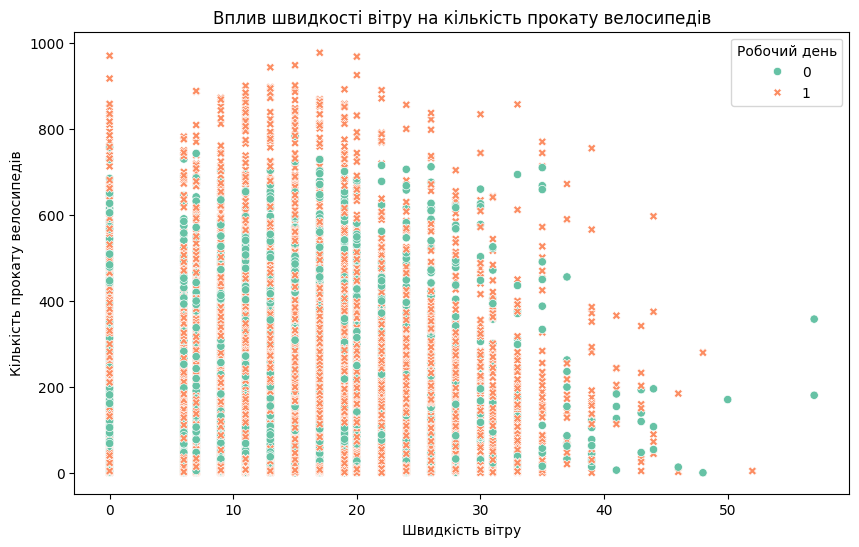

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='windspeed', y='count', hue='workingday', style='workingday', palette='Set2')
plt.title('Вплив швидкості вітру на кількість прокату велосипедів')
plt.xlabel('Швидкість вітру')
plt.ylabel('Кількість прокату велосипедів')
plt.legend(title='Робочий день', loc='upper right')
plt.show()


Спостереження з графіка:

**1. Вплив швидкості вітру на прокат:** Як видно з графіка, кількість прокату велосипедів поступово зменшується зі збільшенням швидкості вітру

**2. Залежність від дня тижня:** В робочі дні користувачі все ж більше користуються сервісом прокату, ніж у вихідні. Це можна пояснити необхідністю їхати в робочі дні на роботу, у вихідні поїздки на велосипеді - це часто дозвілля, яке змінюється від погоди

**Аналіз 2: Зміна кількості прокату велосипедів протягом дня у святкові та робочі дні**

Для цього аналізу підійде лінійний графік з використанням методу lineplot, що показує зміну кількості прокату велосипедів протягом дня

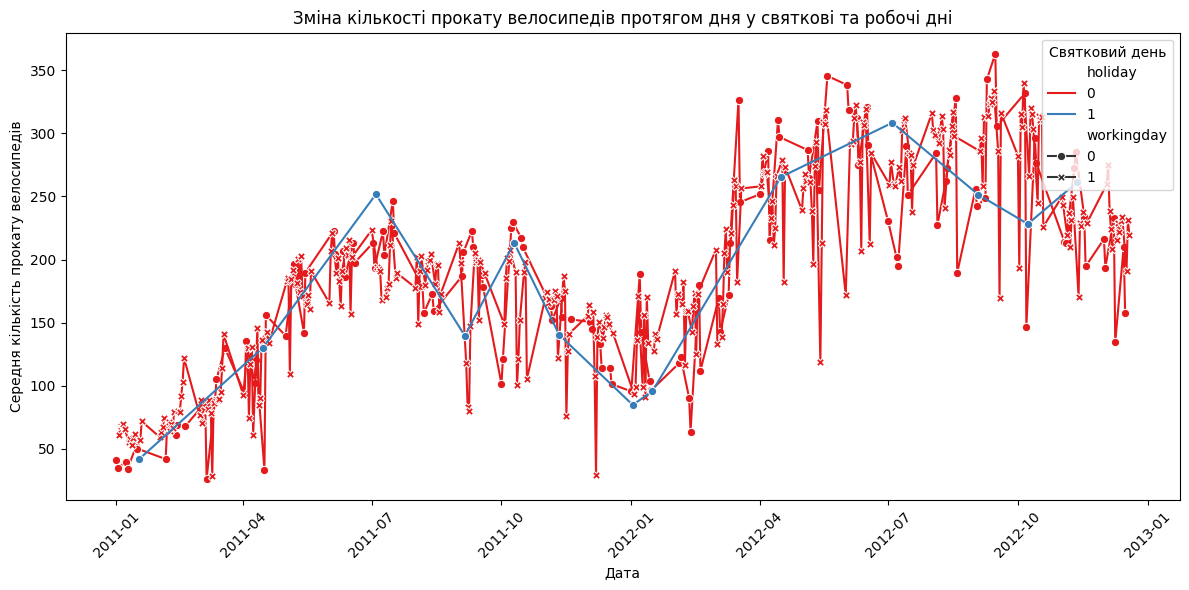

In [ ]:
df['datetime'] = pd.to_datetime(df['datetime'])
df['date'] = df['datetime'].dt.date

daily_rentals = df.groupby(['date', 'holiday', 'workingday'])['count'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_rentals, x='date', y='count', hue='holiday', style='workingday', markers=True, dashes=False, palette='Set1')

plt.title('Зміна кількості прокату велосипедів протягом дня у святкові та робочі дні')
plt.xlabel('Дата')
plt.ylabel('Середня кількість прокату велосипедів')
plt.xticks(rotation=45)
plt.legend(title='Святковий день', loc='upper right')
plt.tight_layout()
plt.show()


Спостереження з графіка:

**1. Прогрес з роками:** Як видно з графіка, кількість прокату велосипедів поступово зростає протягом досліджуваного проміжку часу

**2. Залежність від дня тижня:** Якщо раніше кількість прокатів у вихідні була на рівні з робочими днями, то з часом покращився попит на користування сервісом і в робочі дні.

**3. Сезонність послуги:** Влітку попит на прокат велосипедів прогнозовано вищий, ніж в холодну пору року  

**Аналіз 3: Зміна кількості прокату велосипедів в залежності від погоди у святкові та робочі дні**

Для цього аналізу побудовано діаграму розмаху з вкористанням методу boxplot, що показує розподіл кількості прокату велосипедів для різних типів погоди у святкові і робочі дні.

**Погода:**
1. Ясно, Мало хмарно, частково хмарно
2. Туман + Хмарно, Туман + Розірвані хмари, Туман + Мало хмарно, Туман
3. Легкий сніг, Легкий дощ + Гроза + Розсіяні хмари, Легкий дощ + Розсіяні хмари
4. Сильний дощ + Крижані кулі + Гроза + Туман, Сніг + Туман

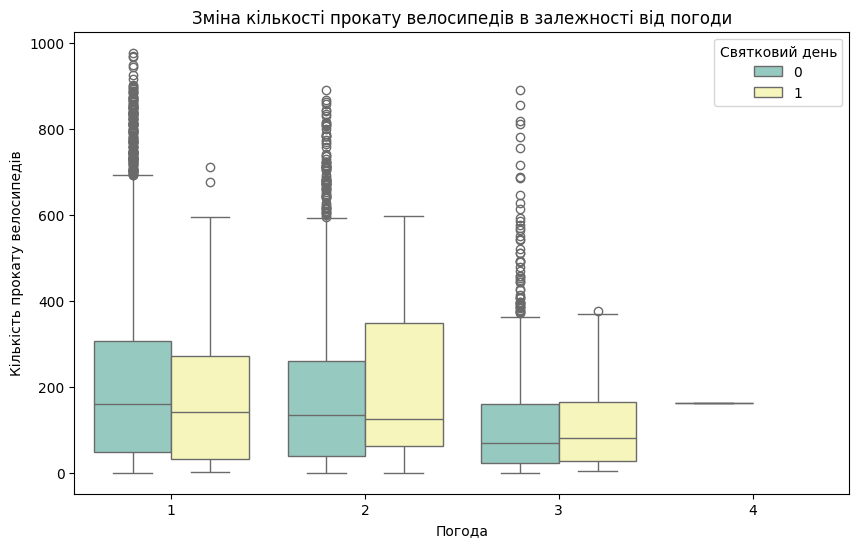

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='weather', y='count', hue='holiday', palette='Set3')
plt.title('Зміна кількості прокату велосипедів в залежності від погоди')
plt.xlabel('Погода')
plt.ylabel('Кількість прокату велосипедів')
plt.legend(title='Святковий день', loc='upper right')
plt.show()


Спостереження з графіка:

**1. Ясно, Мало хмарно, частково хмарно:** У робочі дні кількість прокатів вища, отже можна припустити, що у вихідні дні люди віддають перевагу пішим прогулянкам.  

**2. Туман + Хмарно, Туман + Розірвані хмари, Туман + Мало хмарно, Туман:** Навпаки, більший попит у вихідні дні

**3. Легкий сніг, Легкий дощ + Гроза + Розсіяні хмари, Легкий дощ + Розсіяні хмари:** Кількість прокатів велосипедів помітно зменшилася як у вихідні, так і в робочі дні через менш сприятливі погодні умови

**4. Сильний дощ + Крижані кулі + Гроза + Туман, Сніг + Туман:** У таку погоду попит на прокат велосипедів невеликий у робочі та відсутній у святкові дні